In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
fs = 4.092e6
fc = 1571.328e6

In [32]:
# DATA_OUT, CLK_SER, TIME_SYNC, DATA_SYNC
data = np.genfromtxt("/mnt/c/Users/Nathan/Documents/GPS/digital.csv", dtype=np.uint8, delimiter=',', skip_header=1, usecols=list(range(1, 5)))

# Sample at falling edges
sample_points = np.where(np.logical_and(data[:-1, 1] == 1, data[1:, 1] == 0))
data = data[sample_points]

In [33]:
print(len(data))

163680


In [34]:
start = np.where(data[:, 3] == 1)[0][0]
data = data[start:]
data = np.reshape(data[:len(data) - len(data)%64], (-1, 4, 16))

In [35]:
data = np.reshape(data, (-1, 4, 16))
data = (((data[:, 0] << 1) | data[:, 1]), ((data[:, 2] << 1) | data[:, 3])) # re, im
# data = (((data[:, 3] << 1) | data[:, 0]), ((data[:, 1] << 1) | data[:, 2])) # re, im
data = (data[0].flatten(), data[1].flatten())
data = np.array(data)
data = (data << 6) | 0b100000
data = data.astype(np.int8) / 32
data = data[0] + 1j*data[1]

In [36]:
test = np.random.randint(0, 2, 128)


test = np.reshape(test, (-1, 4, 16))
test = (((test[:, 0] << 1) | test[:, 1]), ((test[:, 2] << 1) | test[:, 3])) # re, im
test = (test[0].flatten(), test[1].flatten())
test = np.array(test)
test = (test << 6) | 0b100000
test = test.astype(np.int8) / 32
test = test[0] + 1j*test[1]


In [37]:
data.shape

(163584,)

1023374.6795263095


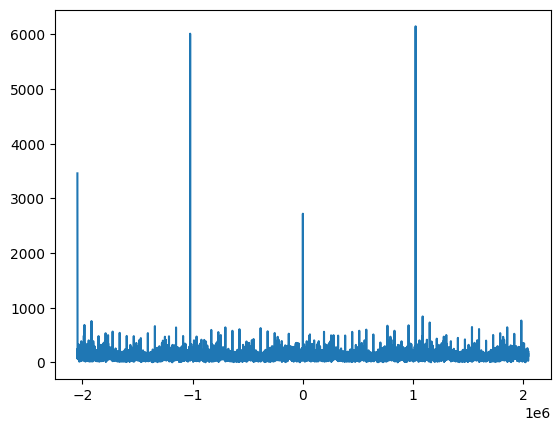

In [38]:
X = np.fft.fftshift(np.fft.fft(data[0:2**13]))
f = np.linspace(-fs/2, fs/2, len(X))

plt.plot(f, np.abs(X))

print(f[np.argmax(np.abs(X))])